In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Churn_Modelling.csv')

In [ ]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
data['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
data.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_set, test_set = train_test_split(data, test_size=0.2, random_state=42)

In [ ]:
X_train = train_set.drop('Exited', axis=1)
y_train = train_set['Exited']
X_test = test_set.drop('Exited', axis=1)
y_test = test_set['Exited']

In [ ]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

In [ ]:
X_train.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('std_scaler', StandardScaler())
    ])
cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="most_frequent")),
        ('encoder', OneHotEncoder())
    ])
full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols),
    ])

In [ ]:
X_train_prepared = full_pipeline.fit_transform(X_train)

In [ ]:
X_train_prepared.shape

(8000, 13)

In [ ]:
from keras.models import Sequential, Model
from keras.layers import Dense, BatchNormalization, Dropout, Input
from keras.optimizers import Adam, SGD, RMSprop

model = Sequential()

model.add(Input(shape=(13,)))
model.add(Dense(30, activation='relu'))
model.add(Dense(40, activation='relu'))
model.add(Dense(25, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 30)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 40)             │         1,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 25)             │         1,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,711 (10.59 KB)

 Trainable params: 2,711 (10.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy',
            optimizer='adam',
            metrics=['accuracy', 'precision', 'recall', 'f1_score'])

In [ ]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(patience=10, restore_best_weights=True)
history = model.fit(X_train_prepared, y_train,
                    epochs=6, batch_size=32,
                    validation_split=5/60,
                    callbacks=[early_stopping]
                    )

Epoch 1/6
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8670 - f1_score: 0.3408 - loss: 0.3192 - precision: 0.7685 - recall: 0.5046 - val_accuracy: 0.8501 - val_f1_score: 0.3429 - val_loss: 0.3539 - val_precision: 0.7065 - val_recall: 0.4710
Epoch 2/6
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8659 - f1_score: 0.3408 - loss: 0.3183 - precision: 0.7623 - recall: 0.5046 - val_accuracy: 0.8501 - val_f1_score: 0.3429 - val_loss: 0.3541 - val_precision: 0.7317 - val_recall: 0.4348
Epoch 3/6
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8714 - f1_score: 0.3408 - loss: 0.3154 - precision: 0.7935 - recall: 0.5053 - val_accuracy: 0.8486 - val_f1_score: 0.3429 - val_loss: 0.3552 - val_precision: 0.6796 - val_recall: 0.5072
Epoch 4/6
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8672 - f1_score: 0.3408 - loss: 0.3155 - precision: 0.7634 - recall: 0.5120 - val_accuracy: 0.8456 - val_f1_score: 0.3429 - val_loss: 0.3563 - val_precision: 0.7397 - val_recall: 0

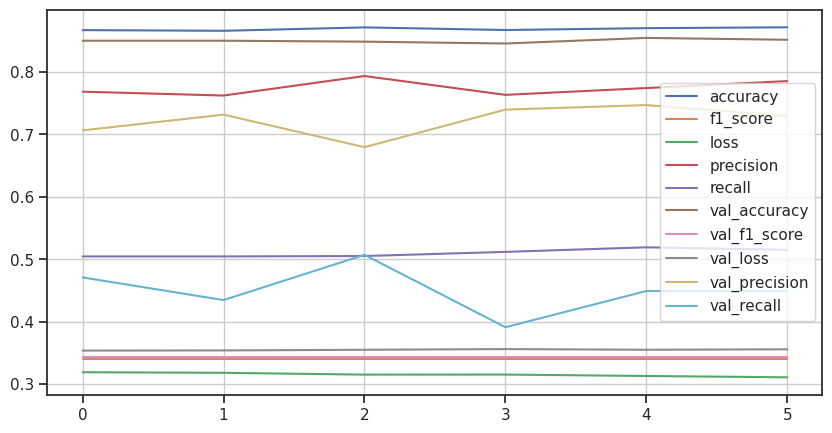

In [ ]:
import matplotlib.pyplot as plt

learning_data = pd.DataFrame(history.history)
learning_data.plot(figsize=(10,5))
plt.grid(True)
plt.show()

In [ ]:
X_test_prepared = full_pipeline.transform(X_test)
model.evaluate(X_test_prepared, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8585 - f1_score: 0.3285 - loss: 0.3387 - precision: 0.6923 - recall: 0.5038


[0.3386526107788086,
 0.8585000038146973,
 0.692307710647583,
 0.5038167834281921,
 0.32845795154571533]